# Dog and Cat classification using CNN-based

In [1]:
import torch
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
import random
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from PIL import Image
import zipfile
import yaml

## Upzip function to unzip dataset
[https://www.dropbox.com/scl/fi/ppd8g3d6yoy5gbn960fso/dataset.zip?dl=0&e=2&file_subpath=%2Fdataset&rlkey=lqbqx7z6i9hp61l6g731wgp4v&st=gdn6pydw](https://www.dropbox.com/scl/fi/ppd8g3d6yoy5gbn960fso/dataset.zip?dl=0&e=2&file_subpath=%2Fdataset&rlkey=lqbqx7z6i9hp61l6g731wgp4v&st=gdn6pydw)

In [2]:
def unzip(zip_path, dest="./datasets", delete_zip=False):
  if not os.path.exists(dest):
    os.makedirs(dest)
  with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(dest)
    print(f"Extracted zip file in: {dest}")
  if delete_zip:
    os.remove(zip_path)
    print(f"Removed zip file in: {zip_path}")


In [3]:
# dataset_dir = "./datasets"
# zipfile_name = "S37 - dataset.zip"
# zip_path = os.path.join(dataset_dir, zipfile_name)
# unzip(zip_path=zip_path, delete_zip=True)

## Get configurations for dataset

In [4]:
with open('config.yaml', 'r') as f:
  config = yaml.safe_load(f)
batch_size = config['dataset']['batch_size']
input_size = config['dataset']['input_size']
root_dir = config['dataset']['root_dir']
val_split = config['dataset']['val_split']
num_workers = config['dataset']['num_workers']
seed = config['seed']
print(seed, root_dir, batch_size, input_size, val_split, num_workers)

42 ./datasets 32 128 0.1 2


## Setting seed for global environment

In [5]:
def seed_all(seed):
  np.random.seed(seed)
  random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

seed_all(seed)

In [6]:
import os
from PIL import Image

def clean_corrupt_images(root_dir):
    deleted_count = 0
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                with Image.open(filepath) as img:
                    img.verify()
            except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                print(f"Error image in: {filepath} -> Erasing")
                os.remove(filepath)
                deleted_count += 1

    print(f"Successfully. Erased {deleted_count} error images.")

# clean_corrupt_images("./datasets/dataset")

## Create data loader getting function

In [7]:
def get_data_loader(root_dir, batch_size=32, input_size=128, val_split=0.1, num_workers=2):
    stats = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    # Preprocessing images
    train_transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(degrees=10, shear=0.2, scale=(0.8,1.2)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    test_transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    base_path = os.path.join(root_dir, "dataset")
    train_dir = os.path.join(base_path, "training_set")
    test_dir = os.path.join(base_path, "test_set")

    if not os.path.exists(train_dir) or not os.path.exists(test_dir):
        raise FileNotFoundError(f"Dataset not found at {train_dir}")

    full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

    class_names = full_train_dataset.classes

    dataset_size = len(full_train_dataset)
    val_size = int(val_split * dataset_size)
    train_size = dataset_size - val_size

    train_subset, val_subset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader, class_names

In [8]:
train_loader, val_loader, test_loader, class_names = get_data_loader(batch_size=batch_size, input_size=input_size, val_split=val_split, root_dir=root_dir, num_workers=num_workers)

In [9]:
print(len(train_loader), len(val_loader), len(test_loader), class_names)

225 25 63 ['cats', 'dogs']


## Define CNN model structure

### Get model configurations

In [10]:
with open('config.yaml', 'r') as f:
  config = yaml.safe_load(f)
in_channels = config['model']['in_channels']
out_channels = config['model']['out_channels']
kernel_size = config['model']['kernel_size']
stride = config['model']['stride']
padding = config['model']['padding']
num_classes = config['model']['num_classes']

print(in_channels, out_channels, kernel_size, stride, padding, num_classes)

3 64 3 1 1 2


### Define CNN model structure

In [11]:
class CNN(nn.Module):
  def __init__(self, num_classes=num_classes, input_size=input_size):
    super(CNN, self).__init__()
    self.input_size = input_size
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=out_channels, out_channels=out_channels*2, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels*2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=out_channels*2, out_channels=out_channels*4, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels*4),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=out_channels*4, out_channels=out_channels*8, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels*8),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.flatten_size = self._get_flatten_size(in_channels, self.input_size)
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(self.flatten_size, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(1024, num_classes),
    )

  def _get_flatten_size(self, in_channels, input_size):
        with torch.no_grad():
            dummy_input = torch.zeros(1, in_channels, input_size, input_size)
            output = self.features(dummy_input)
            return output.view(1, -1).size(1)
  # Forward function
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x


### New structure with SEB blocks to improve performance

In [12]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)
class ModernCNN(nn.Module):
    def __init__(self, config):
        super(ModernCNN, self).__init__()

        in_c = config['model']['in_channels']
        base_c = config['model']['out_channels']
        num_classes = config['model']['num_classes']
        
        self.features = nn.Sequential(
            # Block 1: 3 -> 64
            self._make_block(in_c, base_c),
            
            # Block 2: 64 -> 128
            self._make_block(base_c, base_c*2),
            
            # Block 3: 128 -> 256
            self._make_block(base_c*2, base_c*4),
            
            # Block 4: 256 -> 512
            self._make_block(base_c*4, base_c*8),
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) 
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(base_c*8, num_classes)
        )

    def _make_block(self, in_channels, out_channels):
        """Hàm tạo block: Conv -> BN -> ReLU -> Pool -> SE"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            SEBlock(out_channels)
        )

    def forward(self, x):
        x = self.features(x)      # Output: [B, 512, 8, 8]
        x = self.global_pool(x)   # Output: [B, 512, 1, 1]
        x = self.classifier(x)    # Output: [B, num_classes]
        return x

### Compiling the model

In [13]:
# cnn_model = CNN(num_classes=num_classes, input_size=input_size)   
# print(cnn_model)

## Setting up training section

### Get training configuration

In [14]:
with open('config.yaml', 'r') as f:
  config = yaml.safe_load(f)
learning_rate = config['training']['learning_rate']
num_epochs = config['training']['num_epochs']

patience = config['training']['patience']
min_delta = config['training']['min_delta']
scheduler_factor = config['training']['scheduler_factor']
scheduler_patience = config['training']['scheduler_patience']
save_path = config['training']['save_path']
weight_decay = config['training']['weight_decay']
print(learning_rate, num_epochs, patience, min_delta, scheduler_factor, scheduler_patience, save_path)

0.001 50 10 0.001 0.1 3 ./checkpoints/best_model_final_mcnn.pth


### Early stopping class

In [15]:
class EarlyStopping:
  def __init__(self, patience=patience, verbose=False, delta= 0, path='checkpoint.pth'):
    self.patience = patience
    self.verbose = verbose
    self.counter = 0

    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.inf
    self.delta = delta
    self.path = path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter += 1
      if self.verbose:
        print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...")
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

  def load_checkpoint(self, model):
    model.load_state_dict(torch.load(self.path))
    model.eval()
    print("Model loaded from checkpoint")

## Set up core items

In [16]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cnn_model = cnn_model.to(device)
cnn_model = ModernCNN(config).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
early_stopping = EarlyStopping(patience=patience, delta=min_delta, verbose=True, path=save_path)

## Training loop

In [17]:
import torch
import numpy as np
from tqdm import tqdm

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):
    cnn_model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Train")

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        scores = cnn_model(data)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predictions = scores.max(1)
        train_correct += (predictions == targets).sum().item()
        train_total += targets.size(0)

        loop.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    cnn_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, targets in val_loader:
            data = data.to(device)
            targets = targets.to(device)

            scores = cnn_model(data)
            loss = criterion(scores, targets)

            running_val_loss += loss.item()
            _, predictions = scores.max(1)
            val_correct += (predictions == targets).sum().item()
            val_total += targets.size(0)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"  Val Loss:   {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")
    print(f"  LR: {current_lr}")
    # scheduler.step(epoch_val_loss)
    # Using it for Cosine Annealing 
    scheduler.step()

    early_stopping(epoch_val_loss, cnn_model)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

Epoch [1/50] - Train:  24%|██▍       | 55/225 [00:08<00:24,  6.85it/s, loss=0.664]


KeyboardInterrupt: 

In [18]:
cnn_model.load_state_dict(torch.load(save_path))
cnn_model.eval()

num_correct = 0
num_samples = 0
with torch.no_grad():
  for data, targets in test_loader:
    data = data.to(device=device)
    targets = targets.to(device=device)
    scores = cnn_model(data)
    _, predictions = scores.max(1)
    num_correct += (predictions == targets).sum()
    num_samples += predictions.size(0)

print(f'Final accuracy in test set: {float(num_correct)/float(num_samples)*100:.2f}%')

Final accuracy in test set: 91.70%


## Visualization

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

# 1. Hàm vẽ biểu đồ Loss/Accuracy (Giữ nguyên logic của bạn)
def plot_metrics(train_losses, val_losses, train_accs=None, val_accs=None):
    plt.figure(figsize=(14, 5))

    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='tab:blue')
    plt.plot(val_losses, label='Val Loss', color='tab:orange')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Biểu đồ Accuracy
    if train_accs and val_accs:
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Accuracy', color='tab:green')
        plt.plot(val_accs, label='Val Accuracy', color='tab:red')
        plt.title('Training & Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# 2. Hàm lấy toàn bộ dự đoán (Giữ nguyên)
def get_all_preds(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# 3. Hàm vẽ Confusion Matrix (Giữ nguyên)
def plot_confusion_matrix(model, loader, device, classes=None):
    print("⏳ Đang tính toán Confusion Matrix...")
    preds, labels = get_all_preds(model, loader, device)
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=classes if classes else "auto",
                yticklabels=classes if classes else "auto")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# 4. Hàm hiển thị ảnh sai (ĐÃ SỬA ĐỔI CHO ẢNH MÀU RGB)
def show_misclassified_images(model, loader, device, classes=None, num_images=10):
    print("⏳ Đang tìm kiếm các ảnh bị phân loại sai...")
    preds, labels = get_all_preds(model, loader, device)
    misclassified_idxs = np.where(preds != labels)[0]

    if len(misclassified_idxs) == 0:
        print("Tuyệt vời! Không có ảnh nào bị phân loại sai.")
        return

    print(f"Tìm thấy {len(misclassified_idxs)} ảnh sai. Hiển thị {min(num_images, len(misclassified_idxs))} ảnh đầu tiên.")

    plt.figure(figsize=(20, 8))
    count = 0
    dataset = loader.dataset

    for i, idx in enumerate(misclassified_idxs[:num_images]):
        # Lấy ảnh tensor và nhãn thực
        image_tensor, label = dataset[idx]
        pred_label = preds[idx]

        # --- XỬ LÝ ẢNH ĐỂ HIỂN THỊ ---
        # 1. Chuyển từ Tensor (C, H, W) sang Numpy (H, W, C)
        img = image_tensor.numpy().transpose((1, 2, 0))

        # 2. Denormalize: Hoàn tác bước chuẩn hóa Mean=0.5, Std=0.5
        # Công thức: pixel = pixel * std + mean
        img = img * 0.5 + 0.5

        # 3. Clip giá trị về [0, 1] để tránh lỗi hiển thị
        img = np.clip(img, 0, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img) # Không dùng cmap='gray' cho ảnh màu

        true_text = classes[label] if classes else str(label)
        pred_text = classes[pred_label] if classes else str(pred_label)

        plt.title(f"True: {true_text}\nPred: {pred_text}", color='red', fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

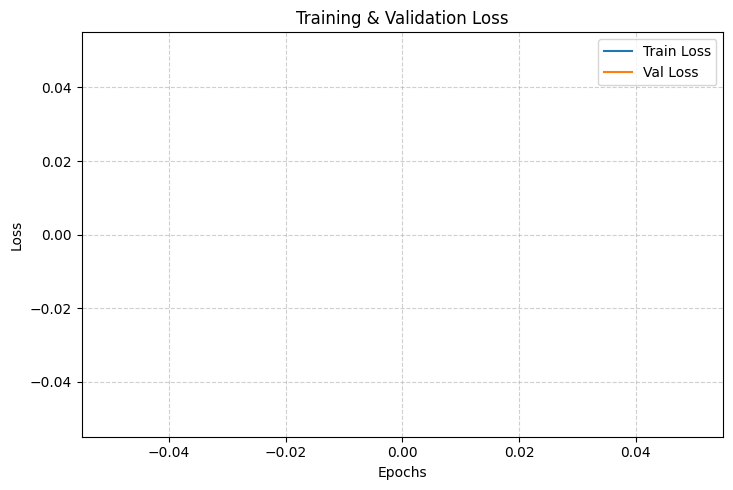

⏳ Đang tính toán Confusion Matrix...


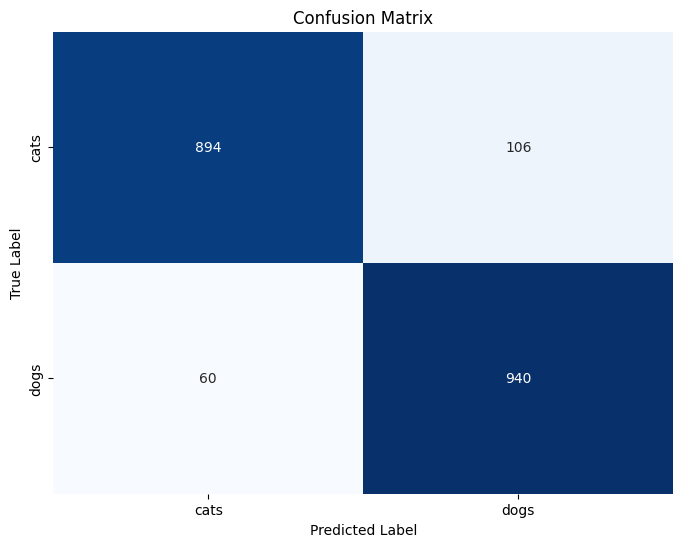

⏳ Đang tìm kiếm các ảnh bị phân loại sai...
Tìm thấy 166 ảnh sai. Hiển thị 10 ảnh đầu tiên.


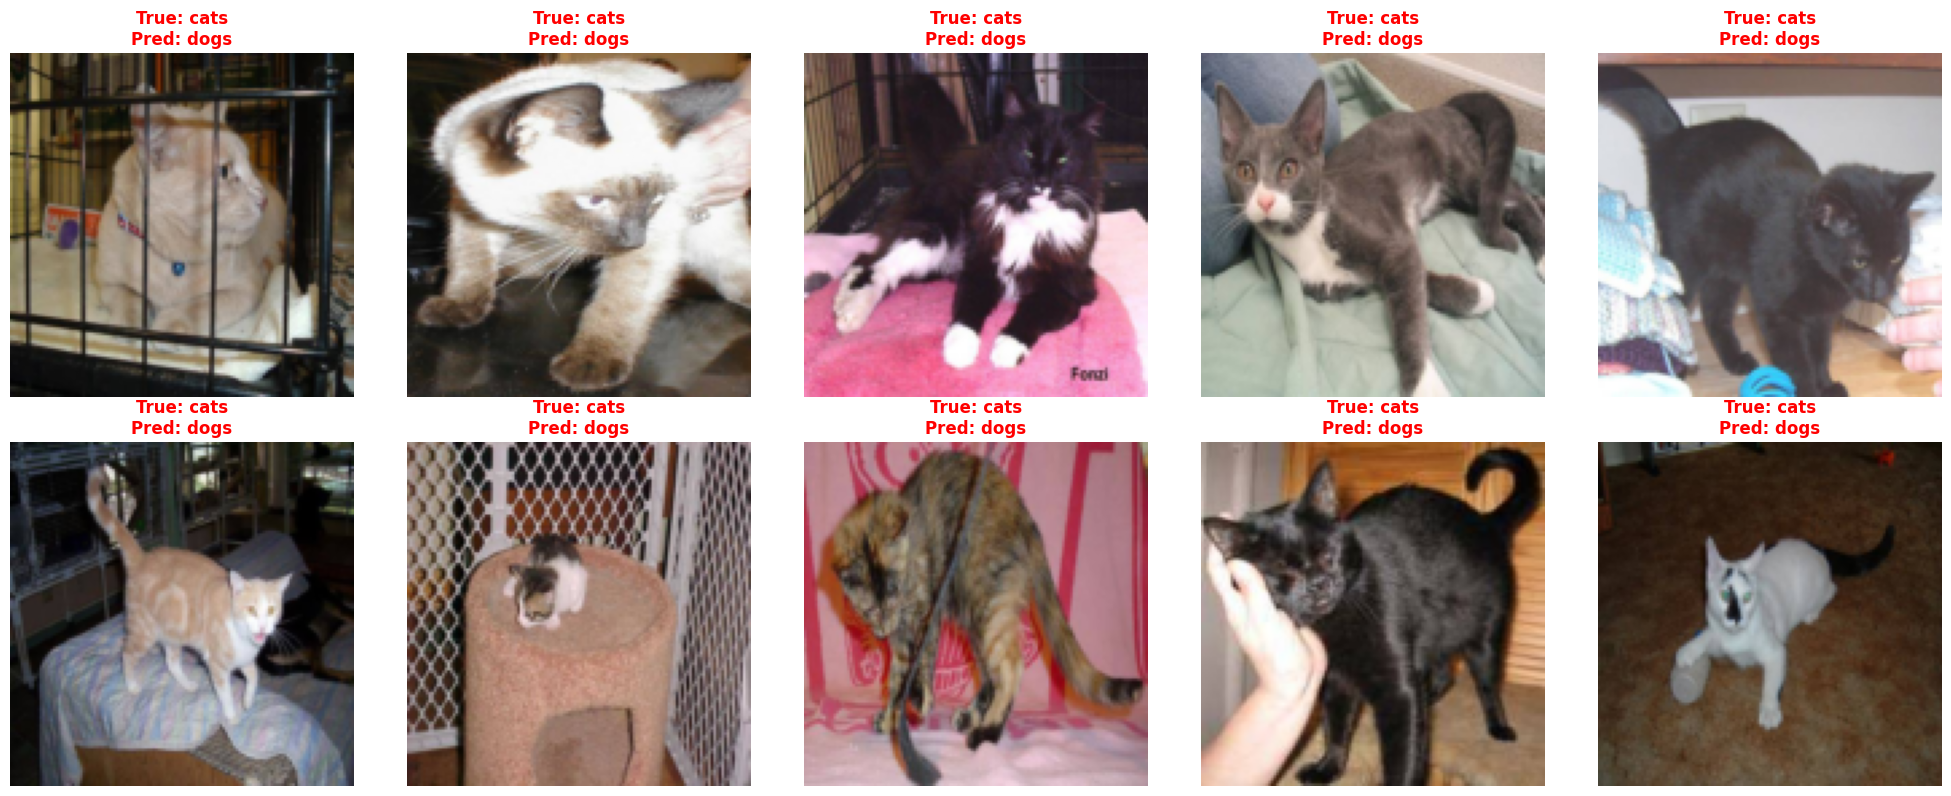

In [20]:
plot_metrics(
    train_losses=train_loss_history,
    val_losses=val_loss_history,
    train_accs=train_acc_history,
    val_accs=val_acc_history
)
plot_confusion_matrix(
    model=cnn_model,
    loader=test_loader,
    device=device,
    classes=class_names
)
show_misclassified_images(
    model=cnn_model,
    loader=test_loader,
    device=device,
    classes=class_names,
    num_images=10
)

## Prediction function

## Prediction function for new images

In [21]:
import math

def predict_new_image(model, device, class_names):
    test_dirs = {
        'cats': './test/cats',
        'dogs': './test/dogs'
    }
    
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    model.eval()
    image_paths = []
    true_labels = []
    
    for label_name, folder_path in test_dirs.items():
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for f in files:
                image_paths.append(os.path.join(folder_path, f))
                true_labels.append(label_name)
    
    num_images = len(image_paths)
    if num_images == 0:
        return

    cols = 4
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(15, rows * 4))

    with torch.no_grad():
        for i, (img_path, true_label) in enumerate(zip(image_paths, true_labels)):
            try:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)
                
                # Predict
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                conf, pred_idx = torch.max(probs, 1)
                pred_label = class_names[pred_idx.item()]
                
                # Plot
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                
                is_correct = (pred_label == true_label)
                color = 'green' if is_correct else 'red'
                
                title = f"True: {true_label}\nPred: {pred_label}\nConf: {conf.item()*100:.1f}%"
                plt.title(title, color=color, fontsize=10, fontweight='bold')
                plt.axis('off')
                
            except Exception as e:
                print(f"Lỗi đọc file {img_path}: {e}")

    plt.tight_layout()
    plt.show()

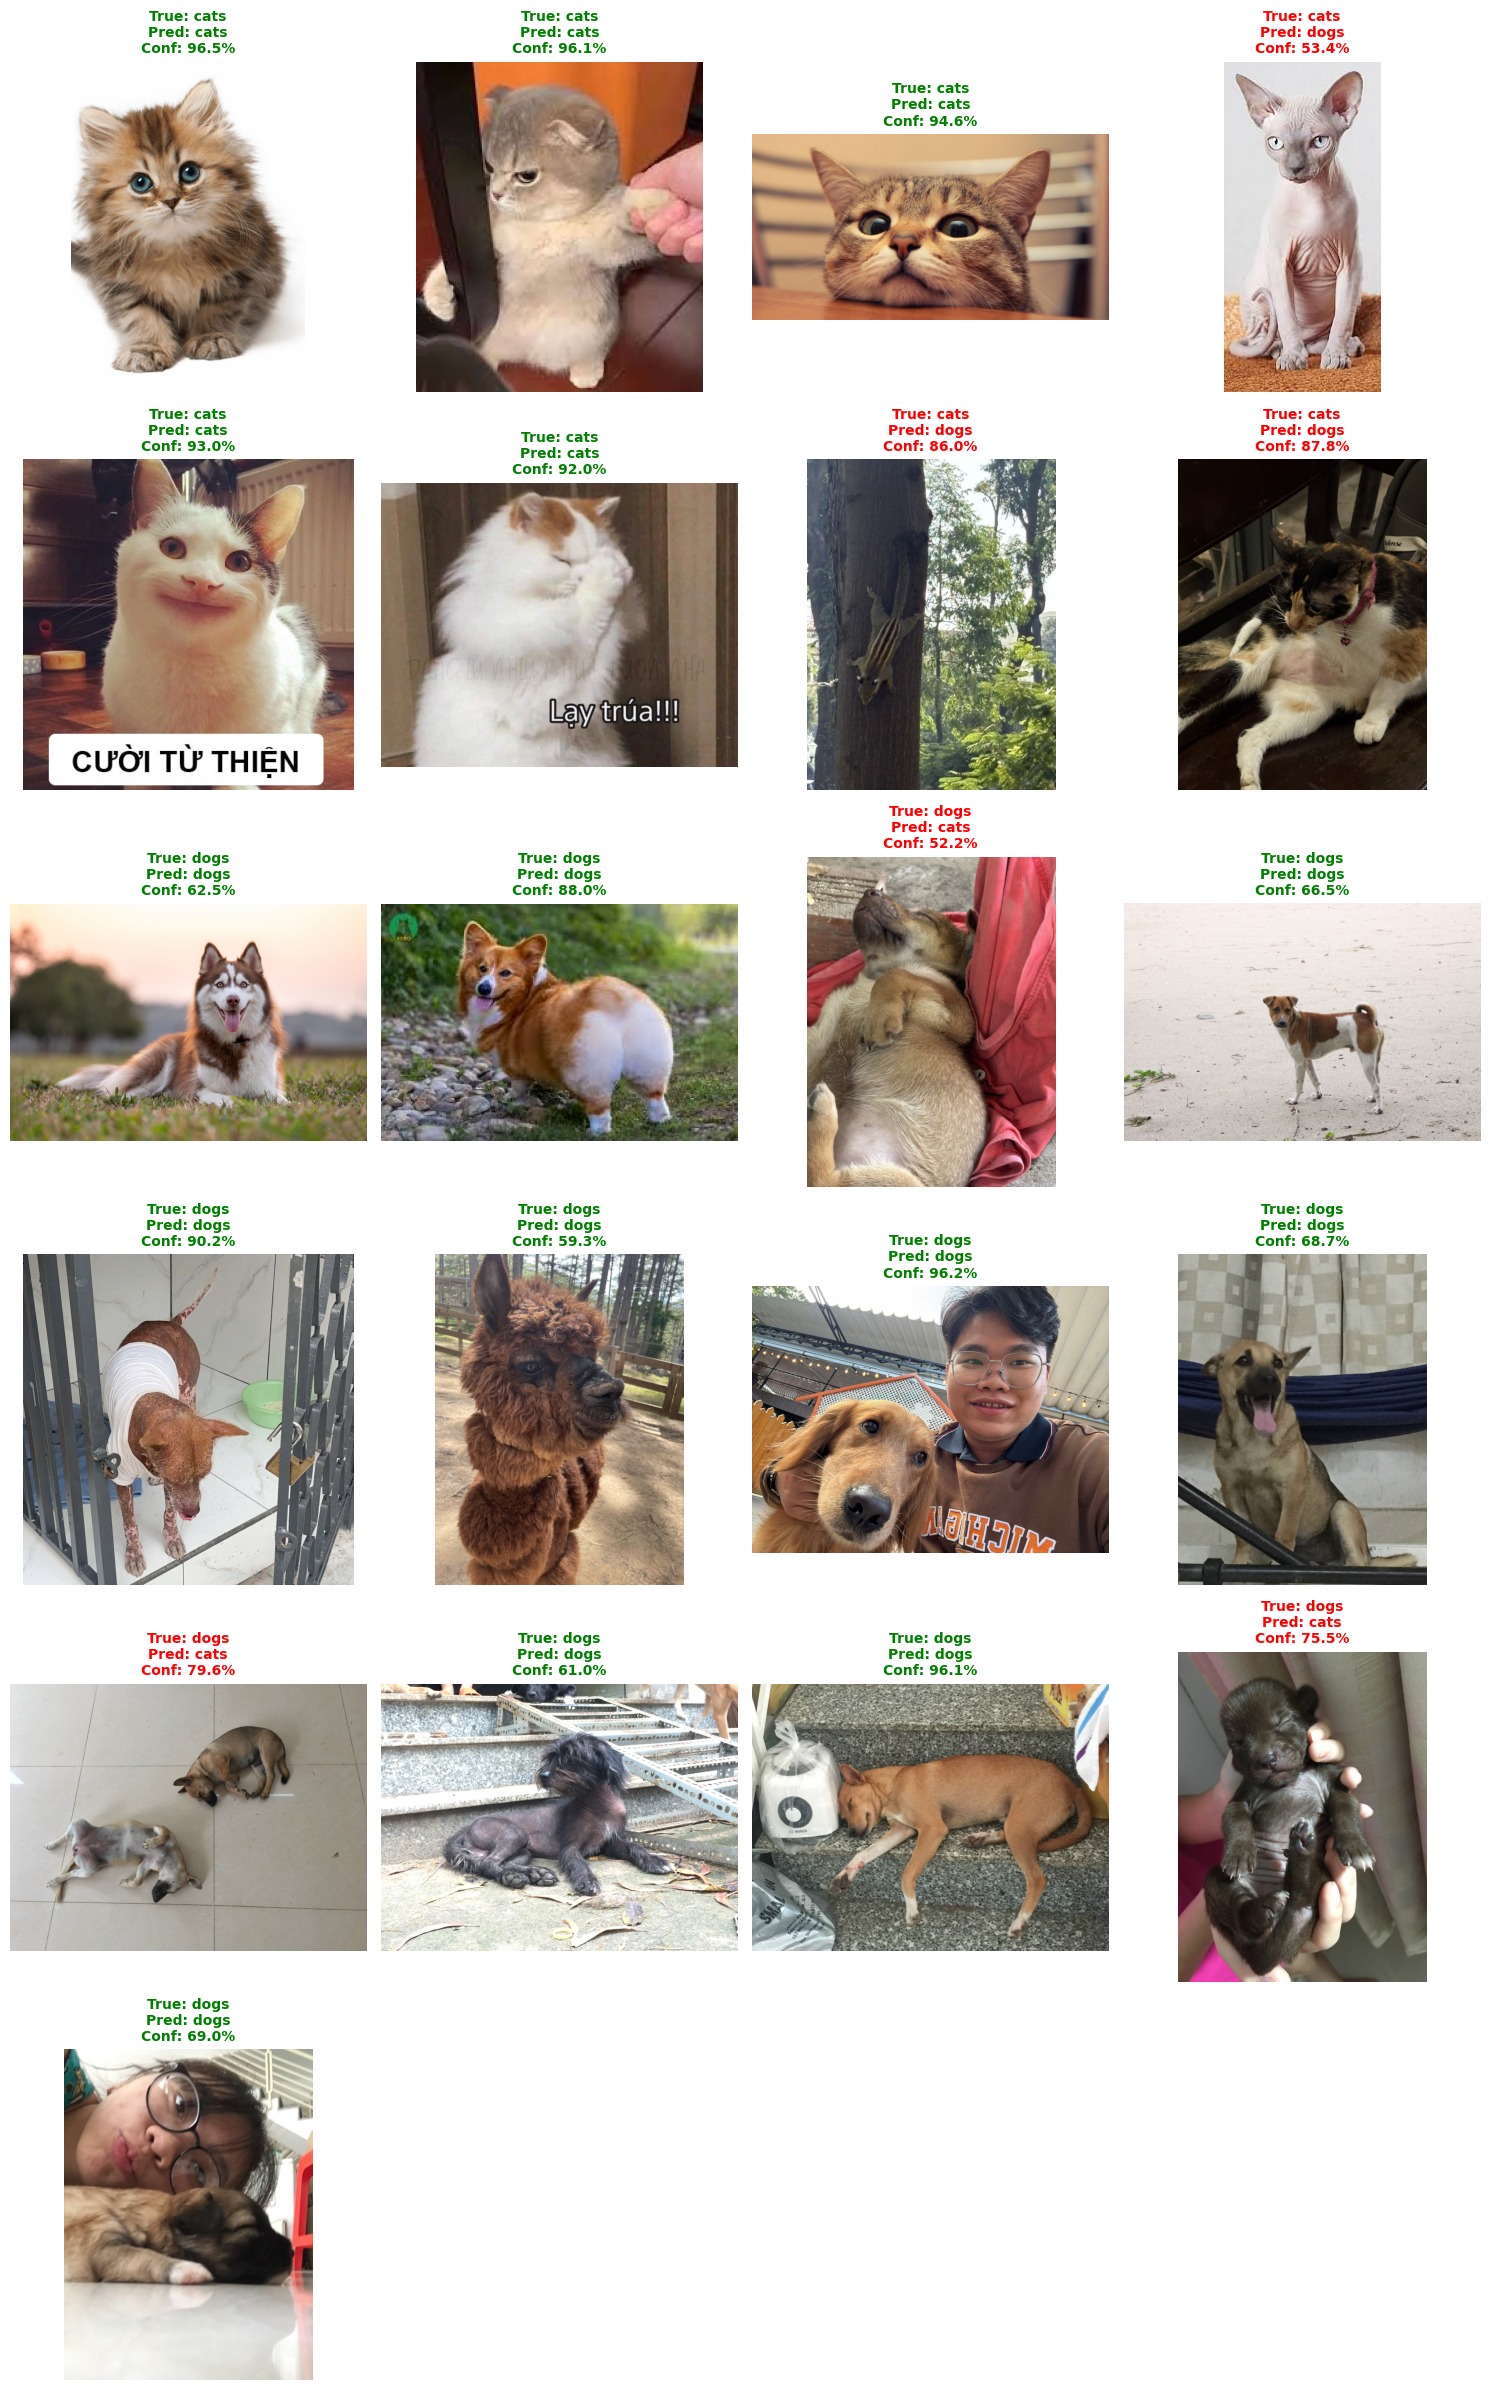

In [22]:
predict_new_image(cnn_model, device, class_names)